In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [3]:
df = pd.read_csv("shopping_behaviour.csv")
print(df.head())
print(df.info())


   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code Used  Previ

In [4]:
df = df.fillna({
    'Review Rating': df['Review Rating'].mean(),
    'Purchase Amount (USD)': df['Purchase Amount (USD)'].mean()
})
df = df.fillna(df.mode().iloc[0])   # Remaining missing values


In [5]:
le = LabelEncoder()
cat_columns = df.select_dtypes(include='object').columns

for col in cat_columns:
    df[col] = le.fit_transform(df[col])


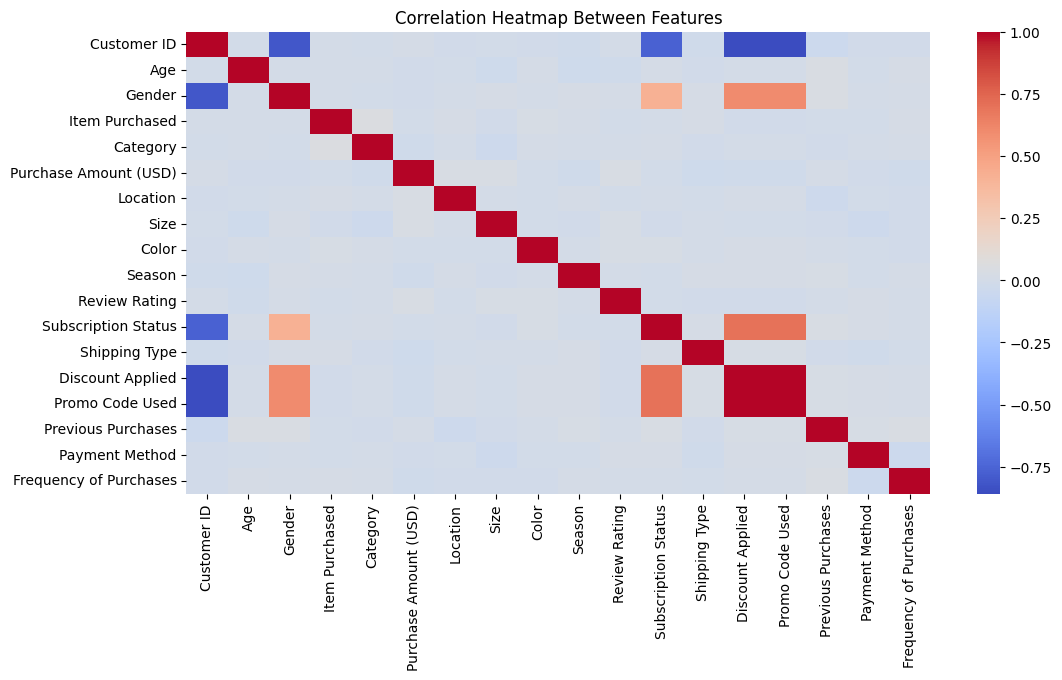

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap Between Features")
plt.show()


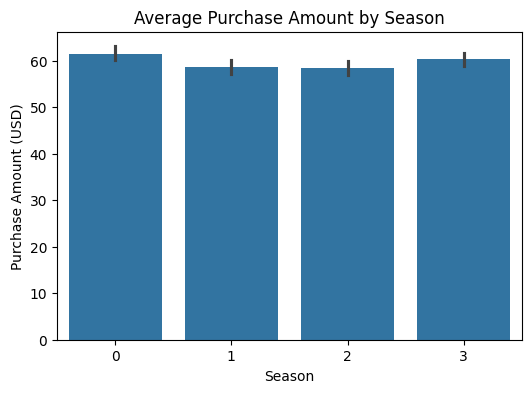

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(x='Season', y='Purchase Amount (USD)', data=df)
plt.title("Average Purchase Amount by Season")
plt.show()


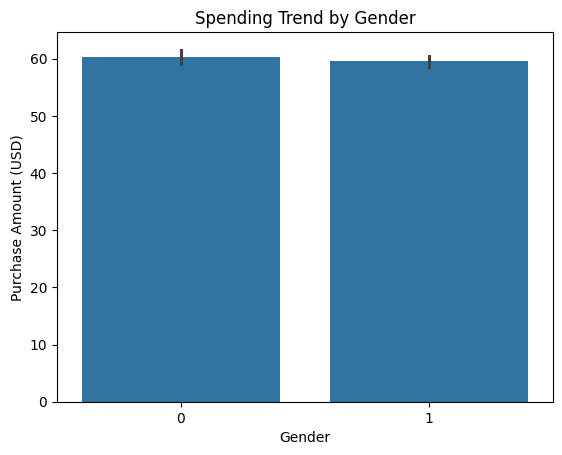

In [8]:
sns.barplot(x='Gender', y='Purchase Amount (USD)', data=df)
plt.title("Spending Trend by Gender")
plt.show()


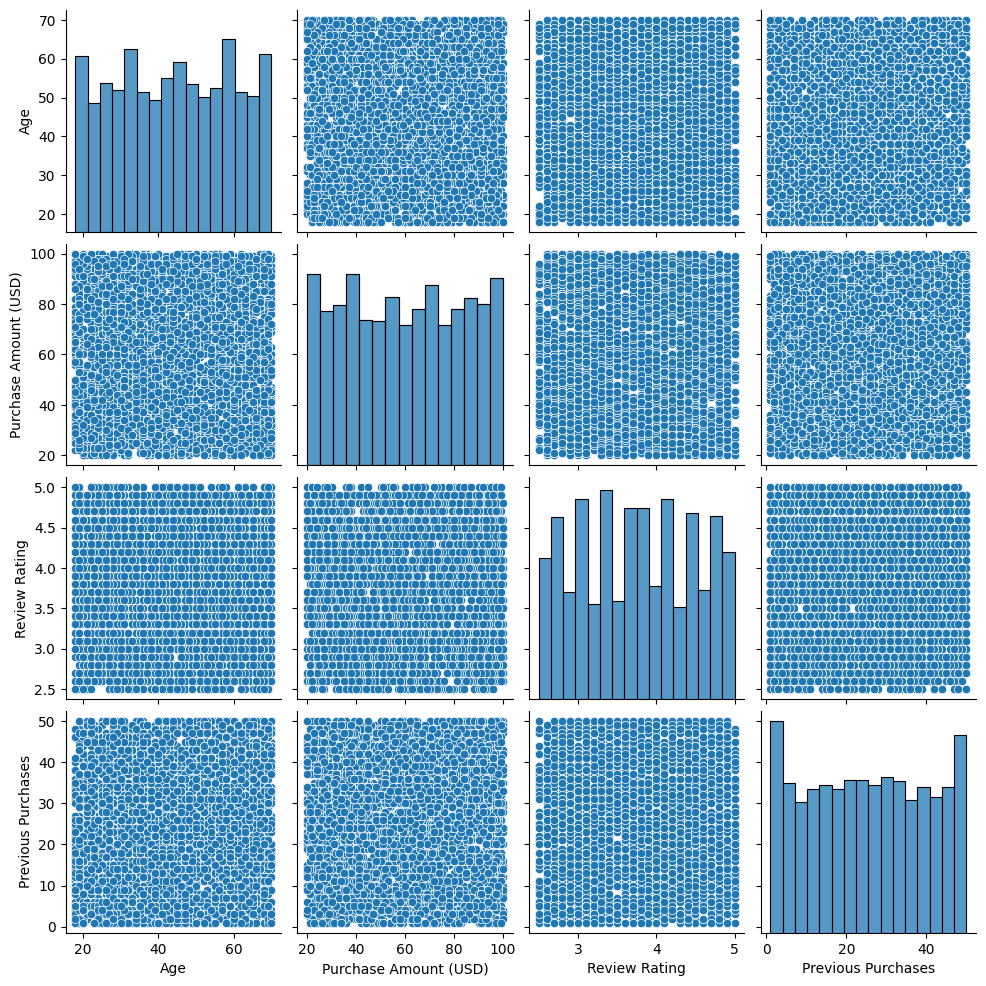

In [9]:
sns.pairplot(df[['Age','Purchase Amount (USD)','Review Rating','Previous Purchases']])
plt.show()


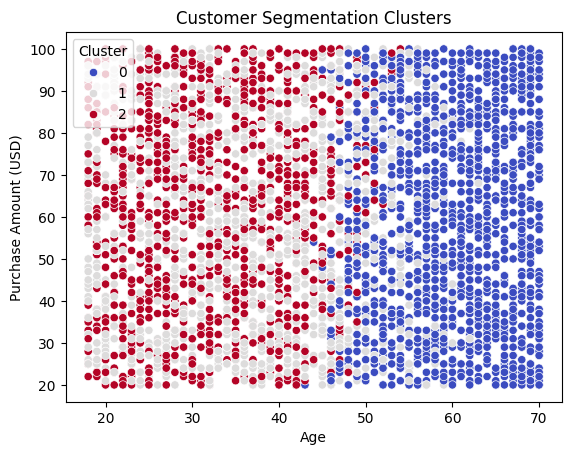

In [10]:
features = df[['Age', 'Purchase Amount (USD)', 'Previous Purchases']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled)

sns.scatterplot(x=df['Age'], y=df['Purchase Amount (USD)'], hue=df['Cluster'], palette='coolwarm')
plt.title("Customer Segmentation Clusters")
plt.show()


In [11]:
X = df.drop(['Subscription Status'], axis=1)
y = df['Subscription Status']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [13]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       558
           1       1.00      1.00      1.00       222

    accuracy                           1.00       780
   macro avg       1.00      1.00      1.00       780
weighted avg       1.00      1.00      1.00       780



In [15]:
df.to_csv("shopping_behaviour_processed.csv", index=False)

import pickle
pickle.dump(model, open("shopping_predict_model.pkl", "wb"))
